In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm, colors
import matplotlib
import seaborn as sns
import numpy as np
from pycirclize import Circos
from pycirclize.utils import ColorCycler
import scipy.stats as stats


In [41]:
excluded_samples=['ST002-1D_LUNG-pacbio-uwsc-group1']


In [42]:
df_pb = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = df_pb['Sample'].str.split('-', expand=True)
#df_pb = df_pb.sort_values(['Donor', 'Tissue', 'Center'])
df_pb['Age'] = np.where(df_pb['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df_ont = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)
#df_ont = df_ont.sort_values(['Donor', 'Tissue', 'Center'])
df_ont['Age'] = np.where(df_ont['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

In [43]:

comb_numt_df = pd.DataFrame()

for sample in df_pb['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])

for sample in df_ont['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])


comb_numt_df[['nchr', 'npos']] = comb_numt_df['qseqid'].str.split('-', expand=True)
#comb_numt_df['npos'] = np.where(comb_numt_df['qstart'].astype(int) > 1, comb_numt_df['npos'].astype(int) + comb_numt_df['qstart'].astype(int) - 1, comb_numt_df['npos'].astype(int))
comb_numt_df = comb_numt_df[comb_numt_df['nchr'] != 'chrM']
comb_numt_df['npos'] = comb_numt_df['npos'].astype(int)
comb_numt_df['strand'] = np.where(comb_numt_df['sstart'].astype(int) < comb_numt_df['send'].astype(int), '+', '-')
comb_numt_df['mstart'] = np.where(comb_numt_df['sstart'].astype(int) < comb_numt_df['send'].astype(int), comb_numt_df['sstart'].astype(int), comb_numt_df['send'].astype(int))
comb_numt_df['mend'] = np.where(comb_numt_df['sstart'].astype(int) >= comb_numt_df['send'].astype(int), comb_numt_df['sstart'].astype(int), comb_numt_df['send'].astype(int))
comb_numt_df['id'] = comb_numt_df['nchr'] + "-" + comb_numt_df['npos'].astype(str) + "-" + comb_numt_df['mstart'].astype(str) + "-" + comb_numt_df['mend'].astype(str)
comb_numt_df = comb_numt_df[['qseqid', 'id', 'nchr', 'npos', 'strand', 'length', 'mstart', 'mend', 'Sample']]
comb_numt_df[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = comb_numt_df['Sample'].str.split('-', expand=True)
#df['Tissue'] = df['Tissue'].str.split('_', expand=True)[1].str.capitalize()

comb_numt_df['Donor+Tissue'] = comb_numt_df['Donor'] + "_" + comb_numt_df['Tissue']

comb_numt_df = comb_numt_df[~(comb_numt_df['Sample'].isin(excluded_samples))]

comb_numt_df


,qseqid,id,nchr,npos,strand,length,mstart,mend,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue
0,chr1-37611748,chr1-37611748-8935-9006,chr1,37611748,+,72,8935,9006,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG
1,chr1-54625173,chr1-54625173-1573-1613,chr1,54625173,+,41,1573,1613,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG
2,chr2-33667411,chr2-33667411-14777-15022,chr2,33667411,-,246,14777,15022,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG
3,chr4-86138984,chr4-86138984-6170-6216,chr4,86138984,-,47,6170,6216,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG
4,chr5-144790242,chr5-144790242-15178-15506,chr5,144790242,+,329,15178,15506,ST002-1D_LUNG-pacbio-broad,ST002,1D_LUNG,pacbio,broad,None,ST002_1D_LUNG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,chr5-32338477,chr5-32338477-12723-12867,chr5,32338477,-,145,12723,12867,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER
6,chr11-4635113,chr11-4635113-16423-16462,chr11,4635113,-,40,16423,16462,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER
7,chr11-49862017,chr11-49862017-1-60,chr11,49862017,-,60,1,60,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER
8,chr11-100145004,chr11-100145004-11499-11557,chr11,100145004,-,59,11499,11557,ST001-1A_LIVER-ont-bcm,ST001,1A_LIVER,ont,bcm,None,ST001_1A_LIVER


In [44]:
tolerance = 100

df = comb_numt_df.sort_values(
    ['nchr', 'npos', 'mstart', 'mend']
).reset_index(drop=True)

numt_ids = [None] * len(df)
current_id = 1

for i in range(len(df)):
    if numt_ids[i] is not None:
        continue

    numt_ids[i] = f"NUMT_{current_id}"
    current = df.iloc[i]

    # grow cluster forward
    for j in range(i + 1, len(df)):
        row = df.iloc[j]

        if row['nchr'] != current['nchr']:
            break  # sorted by chr

        if abs(row['npos'] - df.loc[i, 'npos']) > tolerance:
            break  # window exceeded

        if (
          #  abs(row['length'] - current['length']) <= tolerance and
            abs(row['mstart'] - current['mstart']) <= tolerance and
            abs(row['mend'] - current['mend']) <= tolerance
        ):
            numt_ids[j] = f"NUMT_{current_id}"

    current_id += 1

df['NUMT_ID'] = numt_ids

rep_cols = {
    'npos':   'npos_rep',
    'length':'length_rep',
    'mstart':'mstart_rep',
    'mend':  'mend_rep'
}

for col, new_col in rep_cols.items():
    df[new_col] = (
        df.groupby('NUMT_ID')[col]
          .transform('median')
          .astype(int)
    )

df['numt_long'] = df['nchr'] + "_" + df['npos_rep'].astype(str) + "_" + df['length_rep'].astype(str) + "_" + df['mstart_rep'].astype(str) + "_" + df['mend_rep'].astype(str)


df

,qseqid,id,nchr,npos,strand,length,mstart,mend,Sample,Donor,...,Seq_Tech,Center,Group,Donor+Tissue,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
0,chr1-37611748,chr1-37611748-8935-9005,chr1,37611748,+,71,8935,9005,ST002-1G_COLON-ont-uwsc,ST002,...,ont,uwsc,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
1,chr1-37611748,chr1-37611748-8935-9006,chr1,37611748,+,72,8935,9006,ST002-1D_LUNG-pacbio-broad,ST002,...,pacbio,broad,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
2,chr1-37611748,chr1-37611748-8935-9006,chr1,37611748,+,72,8935,9006,ST002-1D_LUNG-pacbio-bcm,ST002,...,pacbio,bcm,None,ST002_1D_LUNG,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
3,chr1-37611748,chr1-37611748-8935-9006,chr1,37611748,+,72,8935,9006,ST002-1G_COLON-pacbio-washu,ST002,...,pacbio,washu,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
4,chr1-37611748,chr1-37611748-8935-9006,chr1,37611748,+,72,8935,9006,ST002-1G_COLON-pacbio-broad,ST002,...,pacbio,broad,None,ST002_1G_COLON,NUMT_1,37611748,72,8935,9006,chr1_37611748_72_8935_9006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,chr9-129766,chr9-129766-6226-6420,chr9,129766,-,195,6226,6420,ST003-1Q_BRAIN-pacbio-washu,ST003,...,pacbio,washu,None,ST003_1Q_BRAIN,NUMT_22,129766,195,6226,6420,chr9_129766_195_6226_6420
363,chr9-129766,chr9-129766-6226-6420,chr9,129766,-,195,6226,6420,ST003-1Q_BRAIN-pacbio-broad,ST003,...,pacbio,broad,None,ST003_1Q_BRAIN,NUMT_22,129766,195,6226,6420,chr9_129766_195_6226_6420
364,chr9-129766,chr9-129766-6226-6420,chr9,129766,-,195,6226,6420,ST003-1Q_BRAIN-ont-nygc,ST003,...,ont,nygc,None,ST003_1Q_BRAIN,NUMT_22,129766,195,6226,6420,chr9_129766_195_6226_6420
365,chr9-129766,chr9-129766-6226-6420,chr9,129766,-,195,6226,6420,ST003-1Q_BRAIN-ont-uwsc,ST003,...,ont,uwsc,None,ST003_1Q_BRAIN,NUMT_22,129766,195,6226,6420,chr9_129766_195_6226_6420


In [45]:

high_conf_numts = df.groupby(['numt_long','Donor', 'Tissue']).filter(lambda x: len(x) > 1)
high_conf_numts


low_conf_numts = df.groupby(['numt_long','Donor', 'Tissue']).filter(lambda x: len(x) == 1)
low_conf_numts

,qseqid,id,nchr,npos,strand,length,mstart,mend,Sample,Donor,...,Seq_Tech,Center,Group,Donor+Tissue,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
44,chr1-230505699,chr1-230505699-2489-3932,chr1,230505699,+,1457,2489,3932,ST004-1Q_BRAIN-ont-uwsc,ST004,...,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_3,230505699,1457,2489,3932,chr1_230505699_1457_2489_3932
161,chr14-25947180,chr14-25947180-5781-5818,chr14,25947180,-,38,5781,5818,ST004-1Q_BRAIN-ont-uwsc,ST004,...,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_9,25947180,38,5781,5818,chr14_25947180_38_5781_5818
237,chr22-40620124,chr22-40620124-3240-4649,chr22,40620124,-,1414,3240,4649,ST004-1Q_BRAIN-ont-uwsc,ST004,...,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_13,40620124,1414,3240,4649,chr22_40620124_1414_3240_4649
238,chr22-40620124,chr22-40620124-3252-4269,chr22,40620124,+,1020,3252,4269,ST004-1Q_BRAIN-ont-uwsc,ST004,...,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_14,40620124,1020,3252,4269,chr22_40620124_1020_3252_4269
347,chr7-115030581,chr7-115030581-3218-8492,chr7,115030581,-,5287,3218,8492,ST004-1Q_BRAIN-pacbio-uwsc,ST004,...,pacbio,uwsc,None,ST004_1Q_BRAIN,NUMT_20,115030581,5287,3218,8492,chr7_115030581_5287_3218_8492
366,chrX-111421052,chrX-111421052-3036-3075,chrX,111421052,-,40,3036,3075,ST004-1Q_BRAIN-ont-uwsc,ST004,...,ont,uwsc,None,ST004_1Q_BRAIN,NUMT_23,111421052,40,3036,3075,chrX_111421052_40_3036_3075


In [46]:
def custom_join(series):
    return ','.join(series.astype(str))

collapsed_numt_df = high_conf_numts.groupby(['numt_long', 'length_rep', 'strand', 'Donor', 'Tissue']).agg(
        reps=('numt_long', 'count'), rep_names=('Sample', custom_join)).reset_index()

collapsed_numt_df['Donor_Tissue'] = collapsed_numt_df['Donor'] + "-" + collapsed_numt_df['Tissue']

collapsed_numt_df

,numt_long,length_rep,strand,Donor,Tissue,reps,rep_names,Donor_Tissue
0,chr11_100145004_59_11499_11557,59,-,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-bcm,ST001-1A_LIVER-pacbi...",ST001-1A_LIVER
1,chr11_100145004_59_11499_11557,59,-,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-bcm,ST001-1D_LUNG-pacbio-...",ST001-1D_LUNG
2,chr11_100145004_59_11499_11557,59,-,ST002,1D_LUNG,7,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG
3,chr11_100145004_59_11499_11557,59,-,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-uwsc,ST002-1G_COLON-pacb...",ST002-1G_COLON
4,chr11_4635113_40_16423_16462,40,-,ST001,1A_LIVER,7,"ST001-1A_LIVER-pacbio-bcm,ST001-1A_LIVER-pacbi...",ST001-1A_LIVER
5,chr11_4635113_40_16423_16462,40,-,ST001,1D_LUNG,7,"ST001-1D_LUNG-pacbio-bcm,ST001-1D_LUNG-pacbio-...",ST001-1D_LUNG
6,chr11_4635113_40_16423_16462,40,-,ST002,1D_LUNG,7,"ST002-1D_LUNG-pacbio-broad,ST002-1D_LUNG-pacbi...",ST002-1D_LUNG
7,chr11_4635113_40_16423_16462,40,-,ST002,1G_COLON,6,"ST002-1G_COLON-pacbio-uwsc,ST002-1G_COLON-pacb...",ST002-1G_COLON
8,chr11_4635113_40_16423_16462,40,-,ST003,1Q_BRAIN,6,"ST003-1Q_BRAIN-pacbio-uwsc,ST003-1Q_BRAIN-pacb...",ST003-1Q_BRAIN
9,chr11_4635113_40_16423_16462,40,-,ST004,1Q_BRAIN,6,"ST004-1Q_BRAIN-pacbio-uwsc,ST004-1Q_BRAIN-pacb...",ST004-1Q_BRAIN


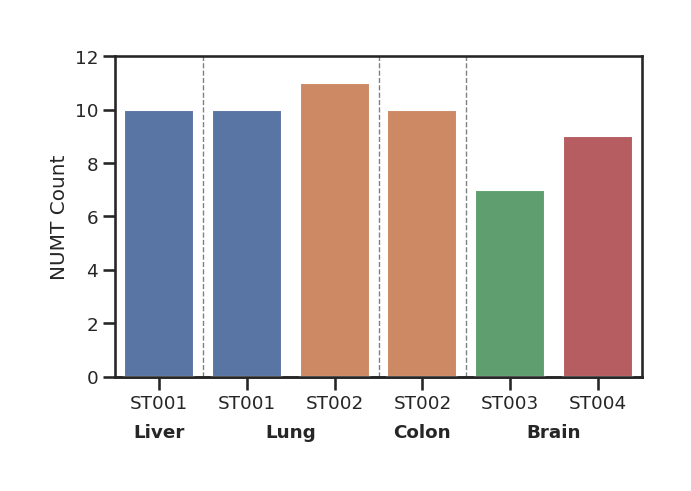

['\n\nLIVER', '\n\nLUNG', '\n\nLUNG', '\n\nCOLON', '\n\nBRAIN', '\n\nBRAIN']


In [ ]:
counts = (
    collapsed_numt_df.groupby("Donor_Tissue", as_index=False)['numt_long'].nunique()
    .rename(columns={"numt_long":"count"})
)
counts[['Donor', 'Tissue']] = counts['Donor_Tissue'].str.split('-', expand=True)

sns.set_theme(style="ticks", context="talk", font_scale=0.8)

fig, ax = plt.subplots(layout='constrained', figsize=(6, 4))

g = sns.barplot(
    data=counts,
    x="Donor_Tissue",
    y="count",
    hue="Donor",
    legend=False,
    ax=ax
)
plt.ylim(0,12)

ticks = ax.get_xticklabels()
labels = [t.get_text() for t in ticks]
donors  = [l.split("-")[0] for l in labels]  
tissues = ['\n\n' + l.split("-")[1].split("_")[1] for l in labels]

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(donors, rotation=0)
ax.set_ylabel("NUMT Count")
ax.set_xlabel("")

sec = ax.secondary_xaxis(location=0)
sec.set_xticks([0,1.5,3,4.5], labels=['\n\nLiver', '\n\nLung', '\n\nColon', '\n\nBrain'])
sec.tick_params('x', length=0)

for tick in sec.get_xticklabels():
    tick.set_fontweight("bold")
    #tick.set_fontsize(14)

midpoints = [0.5,2.5,3.5]
for x in midpoints:
    ax.axvline(x=x,color="gray",linestyle="--",linewidth=1,alpha=1,zorder=0)

plt.savefig(f"plots/fig6-numt_counts.pdf", dpi=300)
plt.show()
print(tissues)

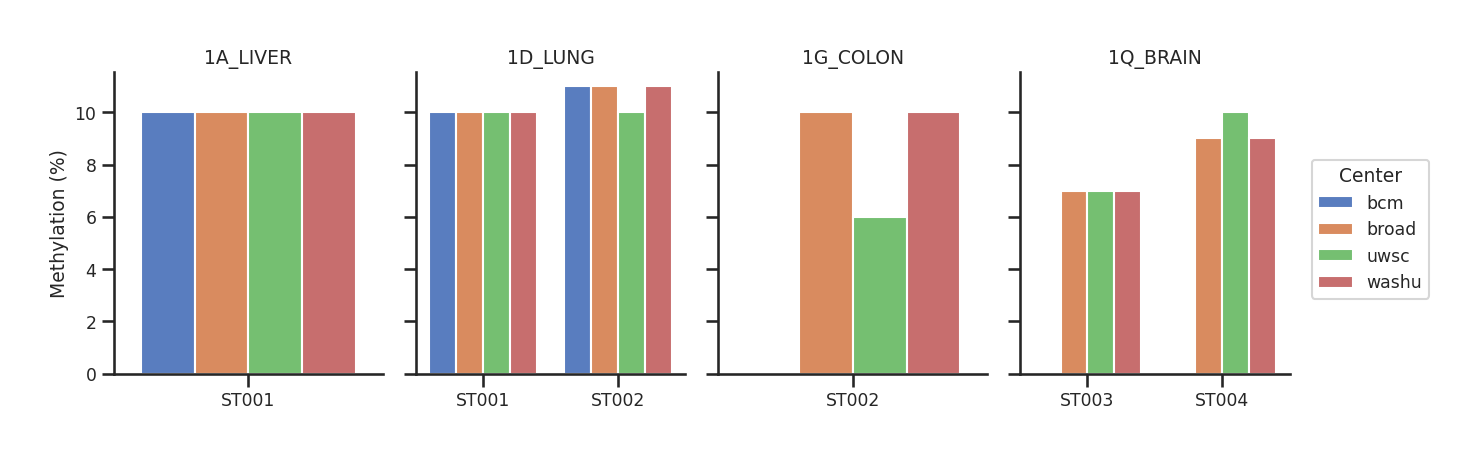

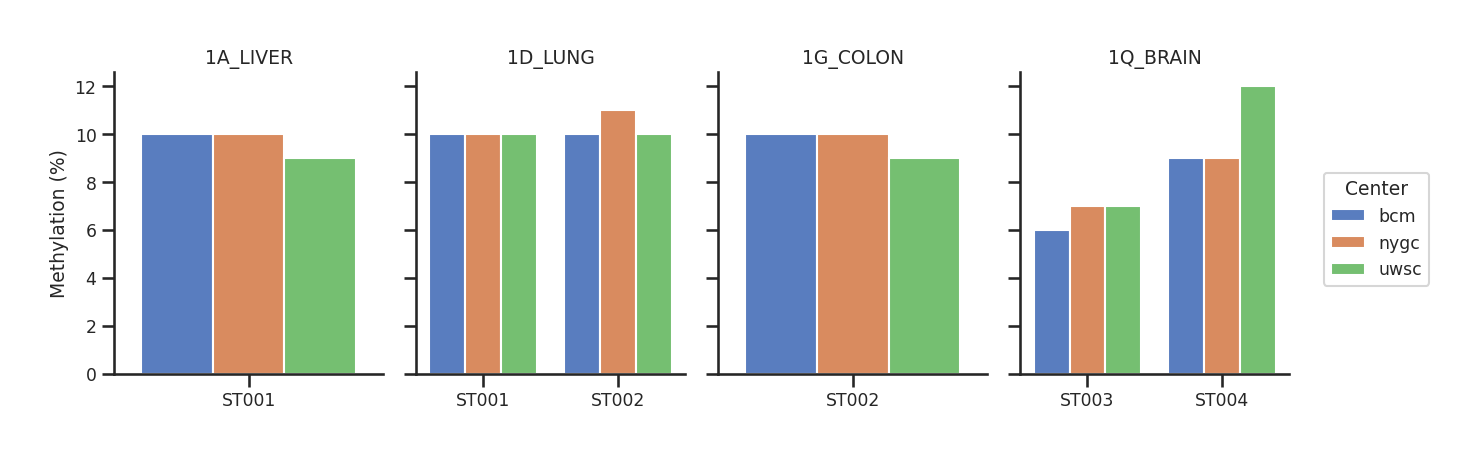

In [48]:
counts_ind = (
    df.groupby("Sample", as_index=False)['numt_long'].nunique()
    .rename(columns={"numt_long":"count"})
)
counts_ind[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = counts_ind['Sample'].str.split('-', expand=True)
counts_ind['Donor+Tissue'] = counts_ind['Donor'] + "_" + counts_ind['Tissue']

counts_ind

sns.set_theme(style="ticks", context="talk", font_scale=0.75)

g = sns.catplot(
    data=counts_ind[counts_ind['Seq_Tech'] == 'pacbio'],
    x="Donor",
    y="count",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=counts_ind[counts_ind['Seq_Tech'] == 'ont'],
    x="Donor",
    y="count",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

In [49]:
print(collapsed_numt_df[['numt_long', 'length_rep']].drop_duplicates()['length_rep'].count())
print(collapsed_numt_df[['numt_long', 'length_rep']].drop_duplicates()['length_rep'].median())
print(collapsed_numt_df[['numt_long', 'length_rep']].drop_duplicates()['length_rep'].mean())
print(collapsed_numt_df[['numt_long', 'length_rep']].drop_duplicates()['length_rep'].std())

17
66.0
152.88235294117646
203.46802032289412


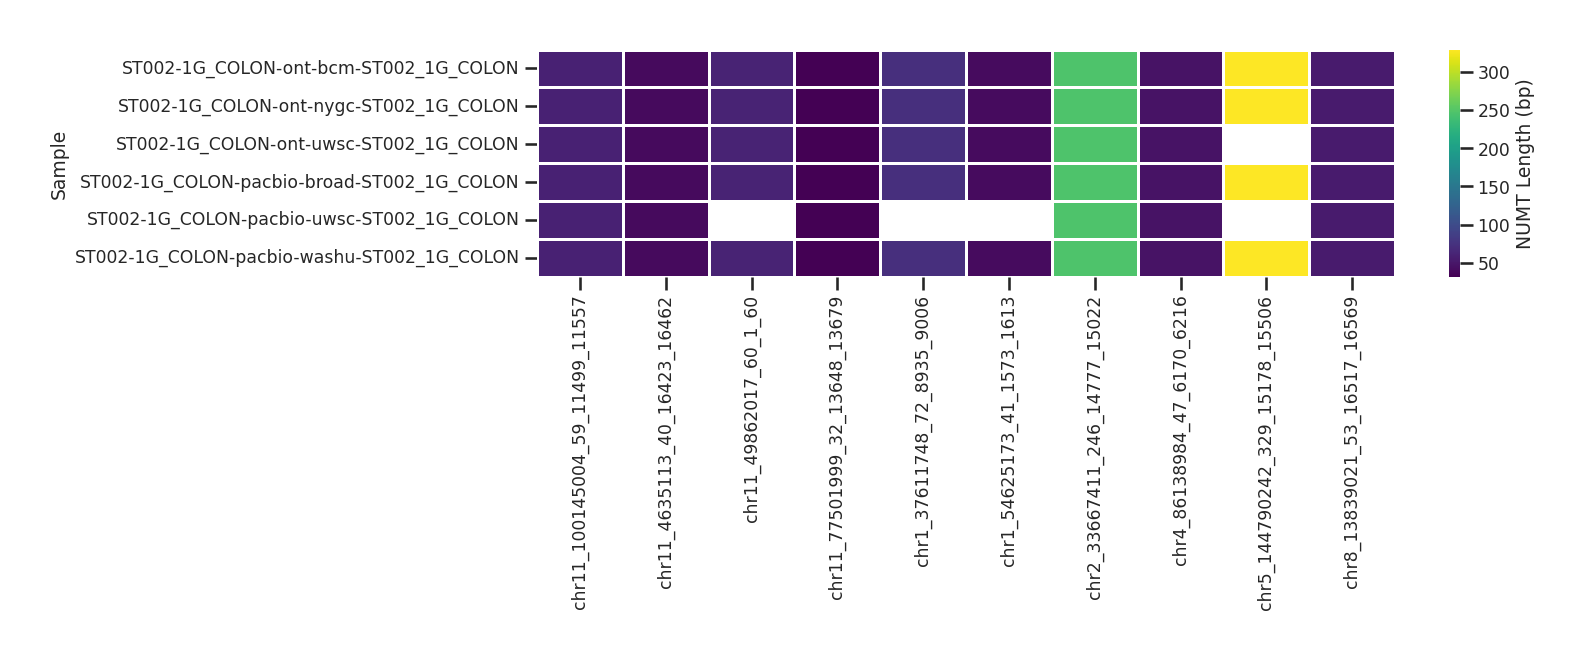

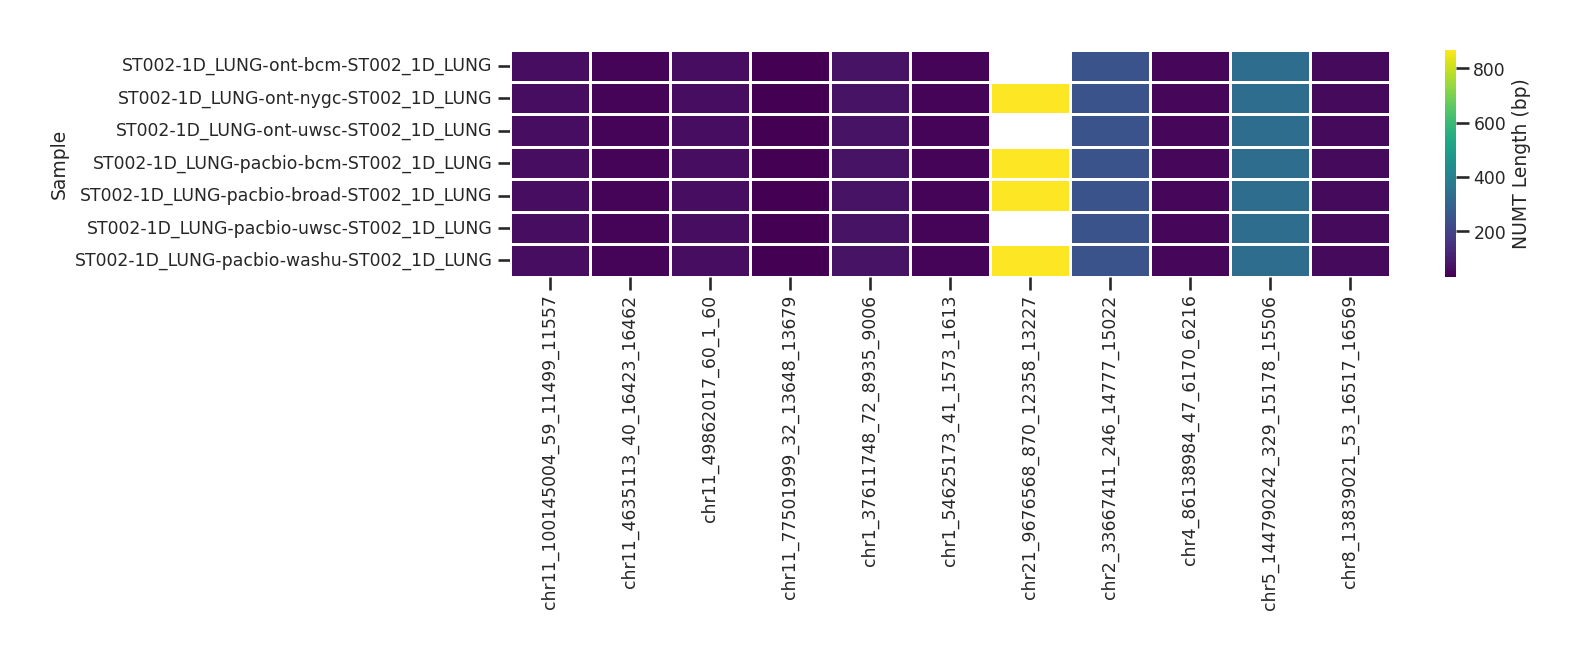

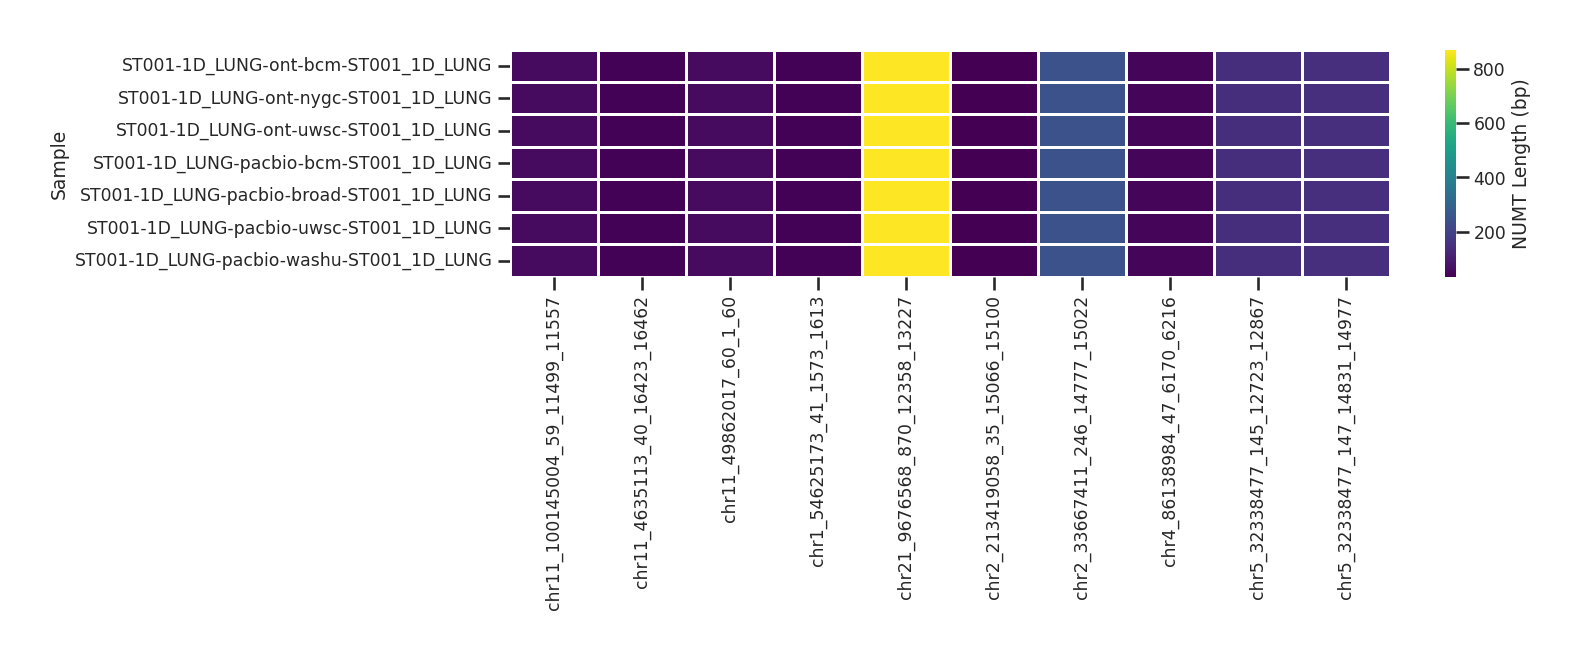

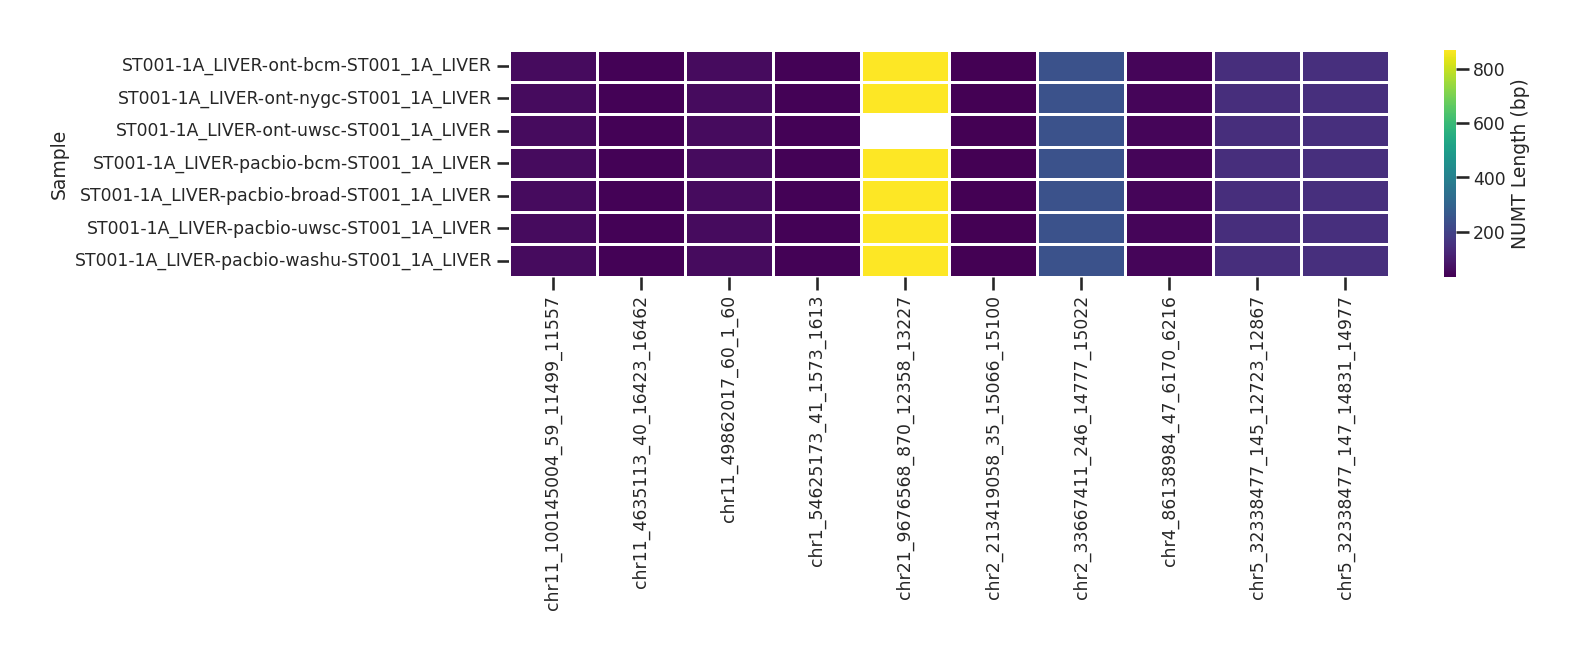

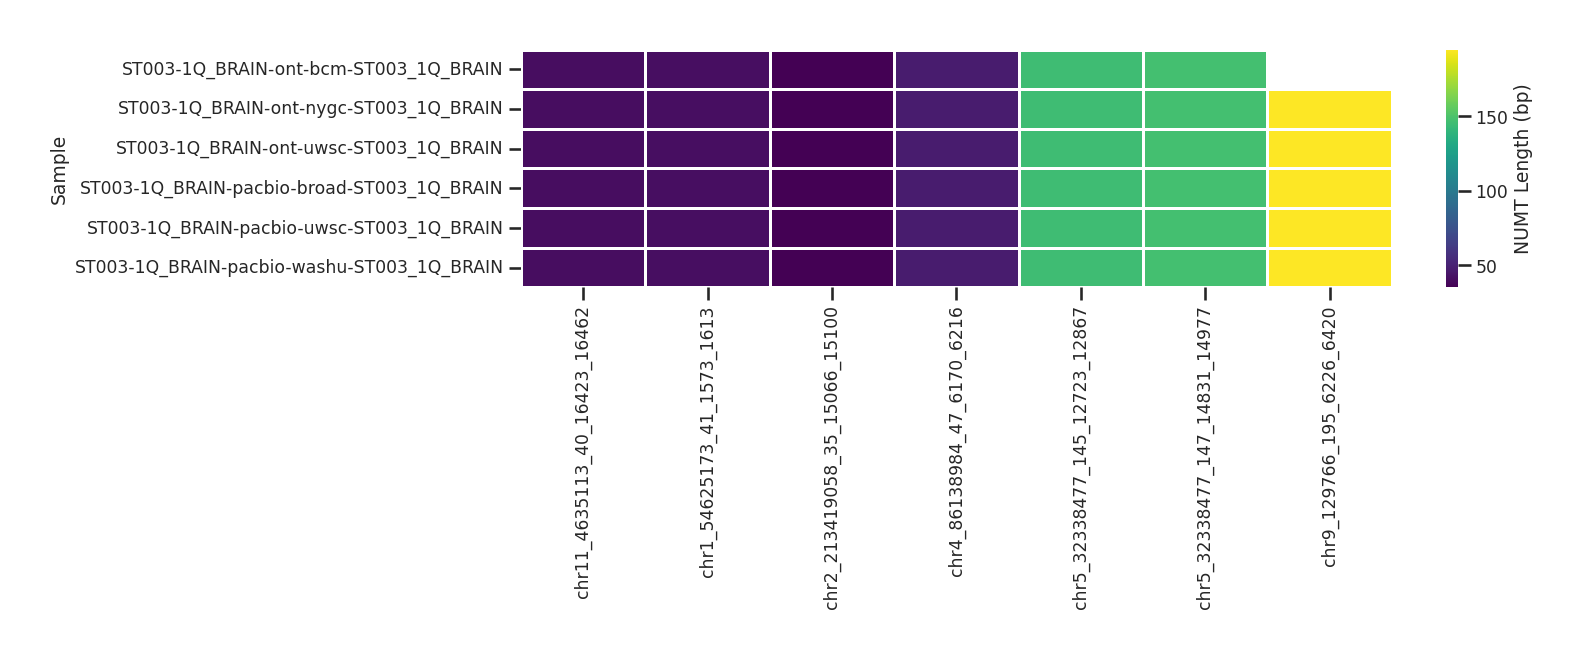

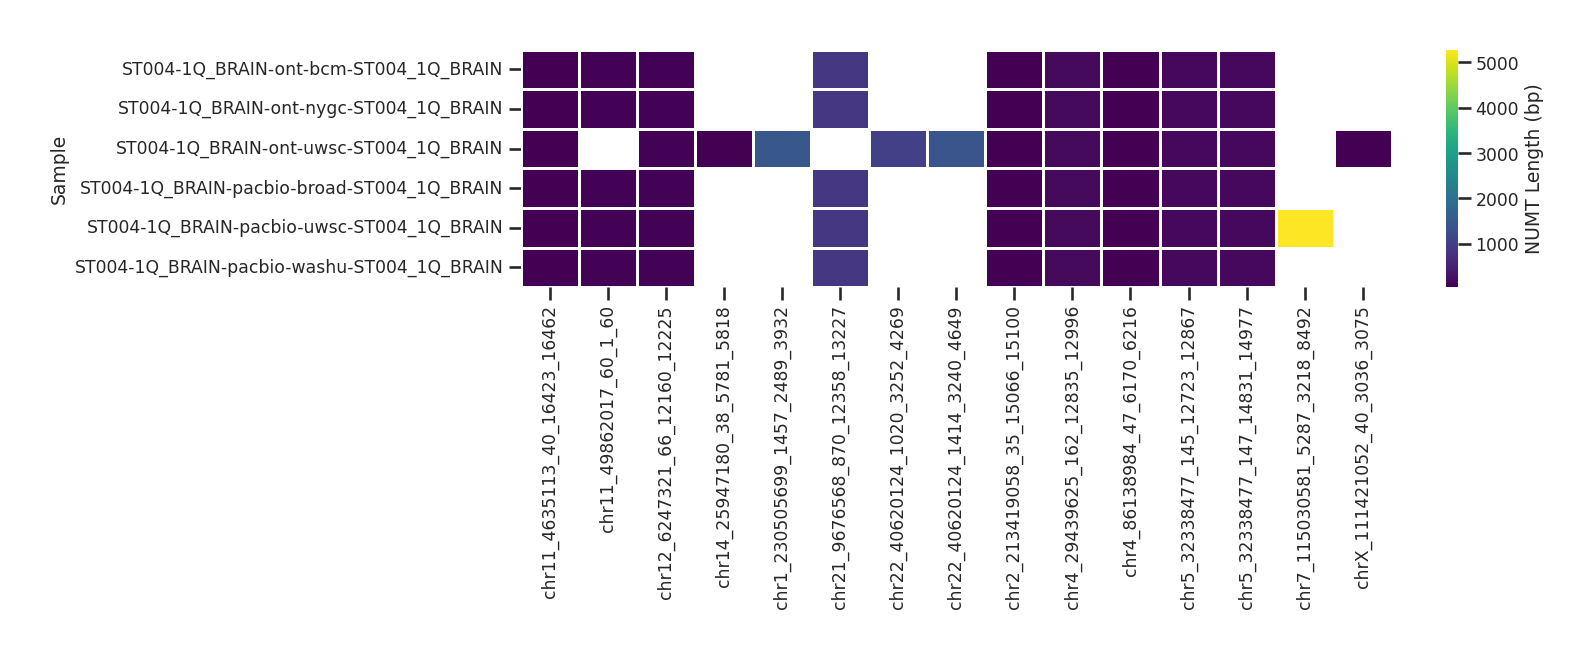

In [50]:

donors = ['ST001', 'ST002', 'ST003', 'ST004']

for d in df['Donor+Tissue'].unique():

    heatmap_data = df[df['Donor+Tissue'] == d].pivot(index=['Sample','Donor+Tissue'], columns='numt_long', values='length_rep')

    # Sort columns by chrom
    #column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    #heatmap_data = heatmap_data[column_order]

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_data, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'NUMT Length (bp)'})
    plt.title('')
    plt.xlabel('')
    plt.ylabel('Sample')
    plt.tight_layout()
    plt.show()


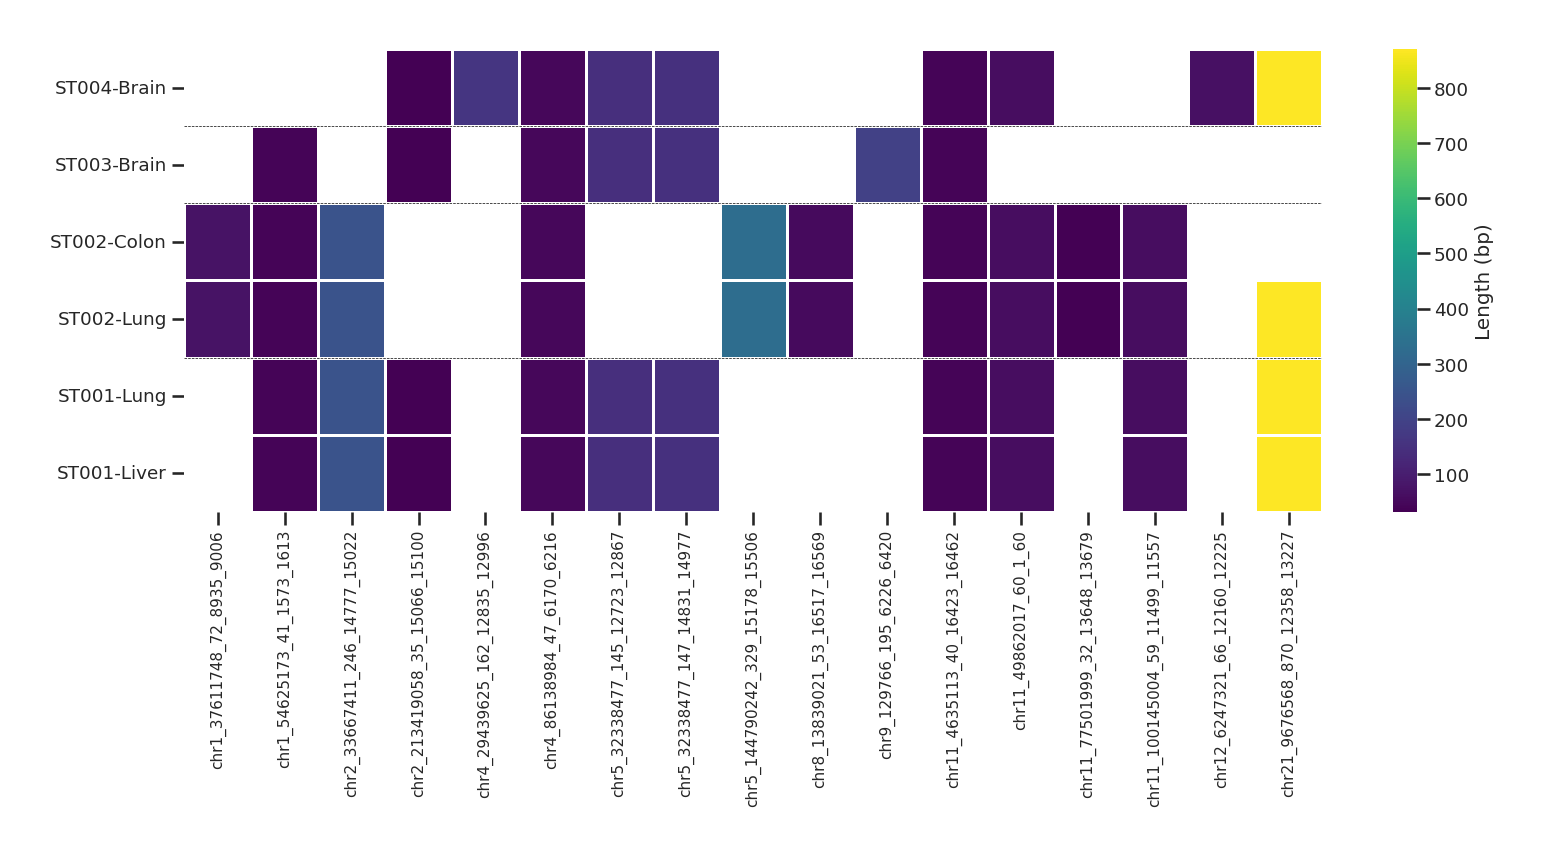

In [51]:

collapsed_numt_df[['nchr', 'npos_rep', 'length_rep2', 'mstart_rep', 'mend_rep']] = collapsed_numt_df['numt_long'].str.split('_', expand=True)
collapsed_numt_df['numt_short'] = collapsed_numt_df['nchr'] + "_" + collapsed_numt_df['npos_rep'] + "_" + collapsed_numt_df['length_rep2']
# Build column order by chromosome → position
collapsed_numt_df['chr_num'] = (
    collapsed_numt_df['nchr']
    .str.replace('chr', '', regex=False)
    .replace({'X': 23, 'Y': 24, 'M': 25})
    .astype(int)
)

collapsed_numt_df['npos_rep'] = collapsed_numt_df['npos_rep'].astype(int)

column_order = (
    collapsed_numt_df[['numt_long', 'chr_num', 'npos_rep']]
    .drop_duplicates()
    .sort_values(['chr_num', 'npos_rep'])
    ['numt_long']
)

collapsed_numt_df['Tissue'] = collapsed_numt_df['Tissue'].str.split('_', expand=True)[1].str.capitalize()
collapsed_numt_df['Donor_Tissue'] = collapsed_numt_df['Donor'] + "-" + collapsed_numt_df['Tissue']
heatmap_data = collapsed_numt_df.sort_values('Donor_Tissue', ascending=True).pivot(index=['Donor_Tissue'], columns='numt_long', values='length_rep')
heatmap_data = heatmap_data[column_order]

sort_order = ["ST004-Brain", "ST003-Brain", "ST002-Colon", "ST002-Lung", "ST001-Lung", "ST001-Liver"]
order_map = {t: i for i, t in enumerate(sort_order)}
heatmap_data = heatmap_data.sort_values(by='Donor_Tissue', key=lambda column: column.map(order_map))

sns.set_theme(style="ticks", context="talk", font_scale=0.8)
plt.figure(figsize=(16, 8))

ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    linewidths=1,
    annot=False,
    cbar_kws={'label': 'Length (bp)'}
)
#ax.invert_yaxis()
row_labels = heatmap_data.index.to_list()
donors = [x.split('-')[0] for x in row_labels]

boundary_positions = [
    i for i in range(1, len(donors))
    if donors[i] != donors[i - 1]
]

for y in boundary_positions:
    ax.hlines(y, *ax.get_xlim(), colors='black', linewidth=0.5,  linestyles='dashed')

plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig(f"plots/fig6-numt_heatmap.pdf", dpi=300)
plt.show()



In [52]:
# count unique samples per NUMT_ID
freq_df = (
    collapsed_numt_df.groupby("numt_long")["Donor_Tissue"]
      .nunique()
      .reset_index(name="freq")
)

collapsed_numt_df = collapsed_numt_df.merge(freq_df, on="numt_long")
#collapsed_numt_df

In [53]:
smaht_unique_numts = collapsed_numt_df[['numt_long', 'nchr', 'npos_rep', 'length_rep', 'mstart_rep', 'mend_rep']].drop_duplicates().reset_index()
smaht_unique_numts

,index,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep
0,0,chr11_100145004_59_11499_11557,chr11,100145004,59,11499,11557
1,4,chr11_4635113_40_16423_16462,chr11,4635113,40,16423,16462
2,10,chr11_49862017_60_1_60,chr11,49862017,60,1,60
3,15,chr11_77501999_32_13648_13679,chr11,77501999,32,13648,13679
4,17,chr12_6247321_66_12160_12225,chr12,6247321,66,12160,12225
5,18,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006
6,20,chr1_54625173_41_1573_1613,chr1,54625173,41,1573,1613
7,25,chr21_9676568_870_12358_13227,chr21,9676568,870,12358,13227
8,29,chr2_213419058_35_15066_15100,chr2,213419058,35,15066,15100
9,33,chr2_33667411_246_14777_15022,chr2,33667411,246,14777,15022


In [54]:
smaht_unique_numts['nchr'].value_counts()

nchr
chr11    4
chr5     3
chr1     2
chr4     2
chr2     2
chr21    1
chr12    1
chr8     1
chr9     1
Name: count, dtype: int64

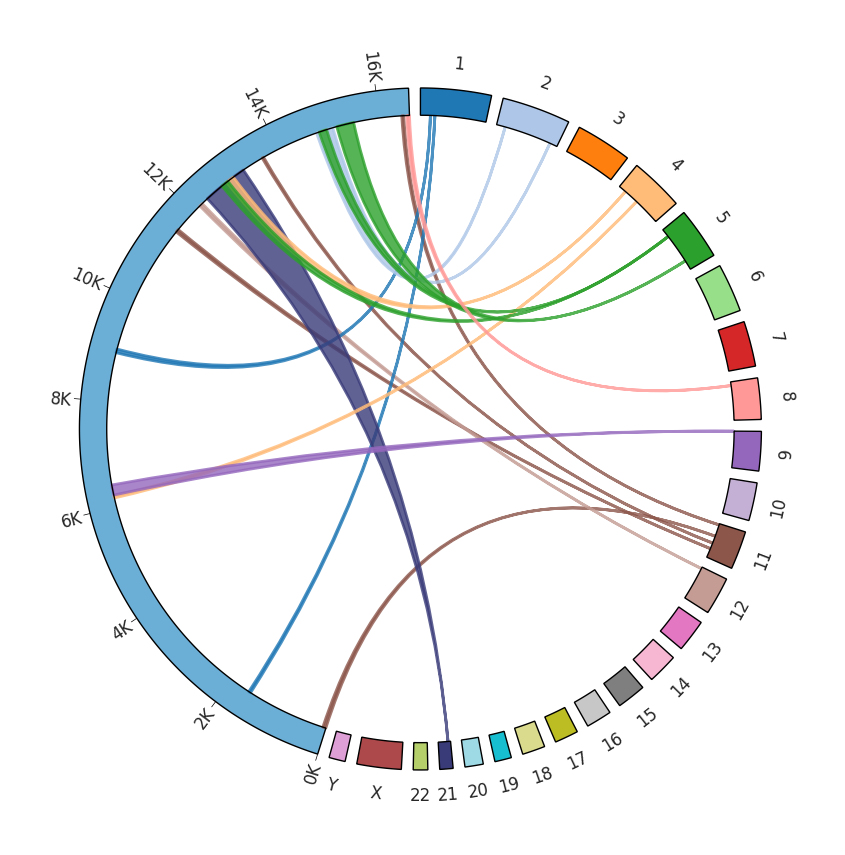

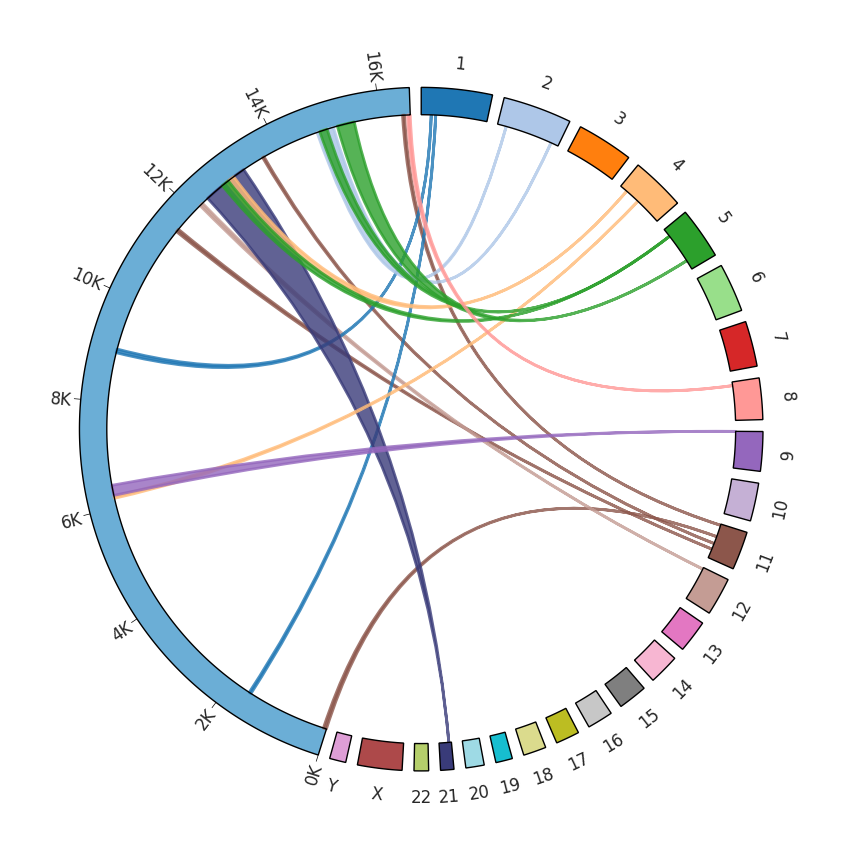

In [55]:
## circos plot 

## ------------------------------------------------------------------ ##
mt_length = 16569 
scale_factor=200000
bed_file = "/net/nwgc/vol1/home/czaka/tools/mitoscope/resources/circos.bed"

# Initialize Circos with space between chromosomes
circos = Circos.initialize_from_bed(bed_file, space=2)
chr_names = [s.name for s in circos.sectors]

# Assign Colors
circos_colors = list(plt.cm.tab20(np.linspace(0, 1, 20)))  # 20 colors
circos_colors += list(plt.cm.tab20b(np.linspace(0, 1, 4)))  # 4 more colors
chr_name2color = {name: color for name, color in zip(chr_names, circos_colors)}

#---- Label chromosomes and draw outer track ----
tick_interval = 2000
positions = [i * scale_factor for i in range(0, mt_length, tick_interval)]
labels = [f"{i//1000}K" for i in range(0, mt_length, tick_interval)]

for sector in circos.sectors:
    track = sector.add_track((92, 100))

    if sector.name in ["chrM", "chrMT"]:
       # sector.text('MT', size=12)
        track.xticks(
            positions,
            labels=labels,
            outer=True,
            label_orientation="vertical",
            label_size=12
        )
        track.axis(fc="#6baed6", lw=1)
    else:
        label = sector.name.replace("chr", "")
        sector.text(label, size=12)
        color = chr_name2color.get(sector.name, "gray")
        track.axis(fc=color, lw=1)
## ------------------------------------------------------------------ ##

smaht_unique_numts['mstart_rep'] = smaht_unique_numts['mstart_rep'].astype(int)
smaht_unique_numts['mend_rep'] = smaht_unique_numts['mend_rep'].astype(int)

# ---- Plot each link ----
for _, row in smaht_unique_numts.iterrows():
    region_mt = ("chrMT", int(row["mstart_rep"]*scale_factor), int(row["mend_rep"]*scale_factor))
    region_nuc = (row["nchr"], int(row["npos_rep"]), int(row["npos_rep"] + 1))
    color = chr_name2color.get(row["nchr"], "blue")

    # norm = colors.Normalize(vmin=collapsed_numt_df["freq"].min(), vmax=collapsed_numt_df["freq"].max())
    # color = cm.viridis(norm(row["freq"]))

    circos.link(region_mt, region_nuc, color=color, alpha=0.8, lw=2)

circos.savefig(f"plots/fig6-numt_circos.pdf", dpi=300)
circos.plotfig()

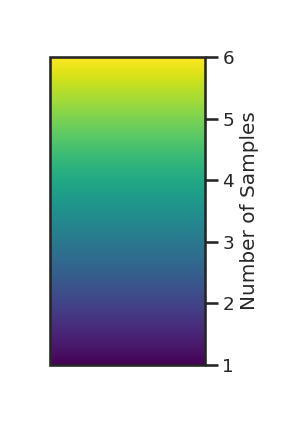

In [56]:
# define colormap and normalization
cmap = cm.viridis
norm = plt.Normalize(vmin=collapsed_numt_df["freq"].min(), vmax=collapsed_numt_df["freq"].max())

# create a dummy figure just for the colorbar
fig, ax = plt.subplots(figsize=(2, 4))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax)
cbar.set_label("Number of Samples")
fig.savefig("colorbar.png", dpi=300, bbox_inches="tight")


In [57]:

seqfirst_numt_df = pd.DataFrame()

seqfirst_pb_samples = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/pacbio/samples_for_merge_pb.csv')
for i in range(0, len(seqfirst_pb_samples)):
    row = seqfirst_pb_samples.iloc[i]
    sample = row['sample']
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/pacbio/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    numt_df['Family_ID_Member'] = row['family_id_member']
    numt_df['Seq_Tech'] = 'pacbio'
    seqfirst_numt_df = pd.concat([seqfirst_numt_df, numt_df])

seqfirst_ont_samples = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/ont/samples_for_merge_ont.csv')
for i in range(0, len(seqfirst_ont_samples)):
    row = seqfirst_ont_samples.iloc[i]
    sample = row['sample']
    if sample != '-':
        file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/seqfirst/ont/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
        numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
        numt_df['Sample'] = sample
        numt_df['Family_ID_Member'] = row['family_id_member']
        numt_df['Seq_Tech'] = 'ont'
        seqfirst_numt_df = pd.concat([seqfirst_numt_df, numt_df])


seqfirst_numt_df[['nchr', 'npos']] = seqfirst_numt_df['qseqid'].str.split('-', expand=True)
seqfirst_numt_df['npos'] = seqfirst_numt_df['npos'].astype(int)
#seqfirst_numt_df['npos'] = np.where(seqfirst_numt_df['qstart'].astype(int) > 1, seqfirst_numt_df['npos'].astype(int) + seqfirst_numt_df['qstart'].astype(int) - 1, seqfirst_numt_df['npos'].astype(int))
seqfirst_numt_df = seqfirst_numt_df[seqfirst_numt_df['nchr'] != 'chrM']
seqfirst_numt_df['strand'] = np.where(seqfirst_numt_df['sstart'].astype(int) < seqfirst_numt_df['send'].astype(int), '+', '-')
seqfirst_numt_df['mstart'] = np.where(seqfirst_numt_df['sstart'].astype(int) < seqfirst_numt_df['send'].astype(int), seqfirst_numt_df['sstart'].astype(int), seqfirst_numt_df['send'].astype(int))
seqfirst_numt_df['mend'] = np.where(seqfirst_numt_df['sstart'].astype(int) >= seqfirst_numt_df['send'].astype(int), seqfirst_numt_df['sstart'].astype(int), seqfirst_numt_df['send'].astype(int))
seqfirst_numt_df['id'] = seqfirst_numt_df['nchr'] + "-" + seqfirst_numt_df['npos'].astype(str) + "-" + seqfirst_numt_df['mstart'].astype(str) + "-" + seqfirst_numt_df['mend'].astype(str)

seqfirst_numt_df = seqfirst_numt_df[['qseqid', 'id', 'nchr', 'npos', 'strand', 'length', 'mstart', 'mend', 'Sample', 'Family_ID_Member', 'Seq_Tech']]

seqfirst_numt_df



,qseqid,id,nchr,npos,strand,length,mstart,mend,Sample,Family_ID_Member,Seq_Tech
0,chr1-54625173,chr1-54625173-1573-1613,chr1,54625173,+,41,1573,1613,1689232,K49199_Proband,pacbio
1,chr2-213419058,chr2-213419058-15066-15100,chr2,213419058,+,35,15066,15100,1689232,K49199_Proband,pacbio
2,chr4-86138984,chr4-86138984-6170-6216,chr4,86138984,-,47,6170,6216,1689232,K49199_Proband,pacbio
3,chr5-32338477,chr5-32338477-14831-14977,chr5,32338477,+,147,14831,14977,1689232,K49199_Proband,pacbio
4,chr5-32338477,chr5-32338477-12723-12867,chr5,32338477,-,145,12723,12867,1689232,K49199_Proband,pacbio
...,...,...,...,...,...,...,...,...,...,...,...
5,chr11-4635113,chr11-4635113-16423-16462,chr11,4635113,-,40,16423,16462,1647125,K49871_Father,ont
6,chr11-49862017,chr11-49862017-1-60,chr11,49862017,-,60,1,60,1647125,K49871_Father,ont
7,chr15-57433966,chr15-57433966-1906-1943,chr15,57433966,-,38,1906,1943,1647125,K49871_Father,ont
8,chr20-21474595,chr20-21474595-1-9526,chr20,21474595,+,9545,1,9526,1647125,K49871_Father,ont


In [58]:
p = pd.merge(seqfirst_pb_samples, seqfirst_ont_samples, on='family_id_member')
p.columns = ['family_id_member', 'pb', 'ont']

pp = p[(p['ont'] == '-') | (p['pb'] == '-')]

only_1_seqtech = pp['family_id_member'].to_list()

## don't include samples that only have PB or only ONT (just use the 359 with both)
seqfirst_numt_df = seqfirst_numt_df[~seqfirst_numt_df['Family_ID_Member'].isin(only_1_seqtech)]


In [59]:

tolerance = 100

df = seqfirst_numt_df.sort_values(
    ['nchr', 'npos', 'mstart', 'mend']
).reset_index(drop=True)

numt_ids = [None] * len(df)
current_id = 1

for i in range(len(df)):
    if numt_ids[i] is not None:
        continue

    numt_ids[i] = f"NUMT_{current_id}"
    current = df.iloc[i]

    # grow cluster forward
    for j in range(i + 1, len(df)):
        row = df.iloc[j]

        if row['nchr'] != current['nchr']:
            break  # sorted by chr

        if abs(row['npos'] - current['npos']) > tolerance:
            break  # window exceeded

        if (
          #  abs(row['length'] - current['length']) <= tolerance and
            abs(row['mstart'] - current['mstart']) <= tolerance and
            abs(row['mend'] - current['mend']) <= tolerance
        ):
            numt_ids[j] = f"NUMT_{current_id}"

    current_id += 1

df['NUMT_ID'] = numt_ids

rep_cols = {
    'npos':   'npos_rep',
    'length':'length_rep',
    'mstart':'mstart_rep',
    'mend':  'mend_rep'
}

for col, new_col in rep_cols.items():
    df[new_col] = (
        df.groupby('NUMT_ID')[col]
          .transform('median')
          .astype(int)
    )

df['numt_long'] = df['nchr'] + "_" + df['npos_rep'].astype(str) + "_" + df['length_rep'].astype(str) + "_" + df['mstart_rep'].astype(str) + "_" + df['mend_rep'].astype(str)

seqfirst_numt_df= df.copy()
seqfirst_numt_df

,qseqid,id,nchr,npos,strand,length,mstart,mend,Sample,Family_ID_Member,Seq_Tech,NUMT_ID,npos_rep,length_rep,mstart_rep,mend_rep,numt_long
0,chr1-8015743,chr1-8015743-7738-7814,chr1,8015743,-,77,7738,7814,1689558,K49844_Proband,pacbio,NUMT_1,8015743,77,7738,7814,chr1_8015743_77_7738_7814
1,chr1-8015743,chr1-8015743-7738-7814,chr1,8015743,-,77,7738,7814,1689559,K49844_Mother,pacbio,NUMT_1,8015743,77,7738,7814,chr1_8015743_77_7738_7814
2,chr1-8015743,chr1-8015743-7738-7814,chr1,8015743,-,77,7738,7814,1642862,K49844_Proband,ont,NUMT_1,8015743,77,7738,7814,chr1_8015743_77_7738_7814
3,chr1-8015743,chr1-8015743-7738-7814,chr1,8015743,-,77,7738,7814,1642863,K49844_Mother,ont,NUMT_1,8015743,77,7738,7814,chr1_8015743_77_7738_7814
4,chr1-37611748,chr1-37611748-8935-9003,chr1,37611748,+,70,8935,9003,1650871,K49278_Mother,ont,NUMT_2,37611748,72,8935,9006,chr1_37611748_72_8935_9006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6226,chrX-46487737,chrX-46487737-914-1196,chrX,46487737,-,283,914,1196,1689247,K49220_Father,pacbio,NUMT_167,46487737,283,914,1196,chrX_46487737_283_914_1196
6227,chrX-46487737,chrX-46487737-914-1196,chrX,46487737,-,283,914,1196,1645705,K49220_Father,ont,NUMT_167,46487737,283,914,1196,chrX_46487737_283_914_1196
6228,chrX-116850352,chrX-116850352-3642-5657,chrX,116850352,+,2017,3642,5657,1689402,K49684_Father,pacbio,NUMT_168,116850352,2024,3642,5657,chrX_116850352_2024_3642_5657
6229,chrX-116850352,chrX-116850352-3642-5657,chrX,116850352,+,2032,3642,5657,1650892,K49684_Father,ont,NUMT_168,116850352,2024,3642,5657,chrX_116850352_2024_3642_5657


In [60]:
t = seqfirst_numt_df.groupby(['numt_long','Family_ID_Member']).agg(reps=('numt_long', 'count')).reset_index()
t.groupby(['reps']).count()

## 84% of NUMT calls in across seqfirst samples have both PB and ONT support


,numt_long,Family_ID_Member
reps,,
1,547,547
2,2842,2842


In [61]:
total_seqfirst_samples = t['Family_ID_Member'].nunique()

seqfirst_PAFs = t.groupby('numt_long').agg(sample_count=('Family_ID_Member', 'count')).reset_index()
seqfirst_PAFs['PAF'] = seqfirst_PAFs['sample_count'] / total_seqfirst_samples

conditions = [
  #  (seqfirst_PAFs['PAF'] >= 0.1),
    (seqfirst_PAFs['PAF'] >= 0.01),
    (seqfirst_PAFs['PAF'] >= 0.001),
    (seqfirst_PAFs['PAF'] < 0.001)

]
choices = ['Common', 'Rare', 'Ultra-rare']
seqfirst_PAFs['Frequency_Group'] = np.select(conditions, choices, default='Unknown')

seqfirst_PAFs['Frequency_Group'].value_counts()

#seqfirst_PAFs


Frequency_Group
Rare      118
Common     51
Name: count, dtype: int64

In [62]:
gen_england_db = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/england_numt_db.csv')
gen_england_db

# gen_england_db['Frequency_group'].value_counts()

gen_england_db['frequency(all populations)']

conditions = [
  #  (gen_england_db['frequency(all populations)'] >= 0.1),
    (gen_england_db['frequency(all populations)'] >= 0.01),
    (gen_england_db['frequency(all populations)'] >= 0.001),
    (gen_england_db['frequency(all populations)'] < 0.001)
]
choices = ['Common', 'Rare', 'Ultra-rare']
gen_england_db['Frequency_Group'] = np.select(conditions, choices, default='Unknown')
gen_england_db['Frequency_Group'].value_counts()


Frequency_Group
Ultra-rare    1567
Rare            49
Common          21
Name: count, dtype: int64

In [63]:
chromosomes = [f'chr{x}' for x in list(range(1, 22)) + ['X', 'Y']]

unique_seqfirst_numts = seqfirst_numt_df[['numt_long', 'nchr', 'npos_rep', 'length_rep', 'mstart_rep', 'mend_rep']].drop_duplicates().reset_index()
unique_seqfirst_numts = unique_seqfirst_numts.drop(columns=['index'])
unique_seqfirst_numts = unique_seqfirst_numts[unique_seqfirst_numts['nchr'].isin(chromosomes)]
unique_seqfirst_numts['nchr'].value_counts()

unique_seqfirst_numts = pd.merge(unique_seqfirst_numts, seqfirst_PAFs, on='numt_long', how='left')

unique_seqfirst_numts.sort_values('sample_count')

,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,sample_count,PAF,Frequency_Group
167,chrX_116850352_5600_10495_16091,chrX,116850352,5600,10495,16091,1,0.002786,Rare
166,chrX_116850352_2024_3642_5657,chrX,116850352,2024,3642,5657,1,0.002786,Rare
11,chr1_220330730_39_4265_4303,chr1,220330730,39,4265,4303,1,0.002786,Rare
12,chr1_228733973_70_3302_3371,chr1,228733973,70,3302,3371,1,0.002786,Rare
26,chr11_88960038_82_5165_5247,chr11,88960038,82,5165,5247,1,0.002786,Rare
...,...,...,...,...,...,...,...,...,...
112,chr5_32338477_145_12723_12867,chr5,32338477,145,12723,12867,258,0.718663,Common
113,chr5_32338477_147_14831_14977,chr5,32338477,147,14831,14977,261,0.727019,Common
100,chr4_86138984_47_6170_6216,chr4,86138984,47,6170,6216,278,0.774373,Common
23,chr11_49862017_60_1_60,chr11,49862017,60,1,60,305,0.849582,Common


In [64]:
# merge seqfirst with gen_england db
seqfirst_merged = unique_seqfirst_numts.merge(gen_england_db, left_on="nchr", right_on="chromosome1",  how="left", suffixes=("", "_db"))
TOL = 100

seqfirst_merged["bp_ok"] = (
    ((abs(seqfirst_merged["nuclearGenome_breakpoint1"] - TOL)) < seqfirst_merged["npos_rep"]) & ((abs(seqfirst_merged["nuclearGenome_breakpoint2"] + TOL)) > seqfirst_merged["npos_rep"]))

seqfirst_merged['diff'] = abs(seqfirst_merged['npos_rep'] - seqfirst_merged['nuclearGenome_breakpoint1'])
seqfirst_merged[seqfirst_merged['bp_ok'] == True]['numt_long'].nunique()

matched_numts = (
    seqfirst_merged
    .loc[seqfirst_merged["bp_ok"], "numt_long"]
    .unique()
)

unique_seqfirst_numts["in_SR_catalog"] = (
    unique_seqfirst_numts["numt_long"].isin(matched_numts)
)

unique_seqfirst_numts.sort_values('sample_count')

#unique_seqfirst_numts[unique_seqfirst_numts['length_rep'] < 500]
## >80% of seqfirst NUMTs are <500bp
unique_seqfirst_numts[unique_seqfirst_numts['in_SR_catalog']]

,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,sample_count,PAF,Frequency_Group,in_SR_catalog
1,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006,99,0.275766,Common,True
4,chr1_60828104_388_866_1253,chr1,60828104,388,866,1253,2,0.005571,Rare,True
6,chr1_118142056_58_2592_2649,chr1,118142056,58,2592,2649,3,0.008357,Rare,True
10,chr1_199834088_36_12209_12244,chr1,199834088,36,12209,12244,2,0.005571,Rare,True
16,chr10_78769260_106_6799_6904,chr10,78769260,106,6799,6904,30,0.083565,Common,True
...,...,...,...,...,...,...,...,...,...,...
157,chr9_70547052_122_7565_7685,chr9,70547052,122,7565,7685,1,0.002786,Rare,True
158,chr9_70916590_115_3907_4021,chr9,70916590,115,3907,4021,2,0.005571,Rare,True
160,chr9_92344697_70_16390_16459,chr9,92344697,70,16390,16459,1,0.002786,Rare,True
161,chr9_110244297_103_7924_8026,chr9,110244297,103,7924,8026,4,0.011142,Common,True


In [65]:
unique_seqfirst_numts.to_csv('tables/seqfirst_unique_numts.csv', index=False)

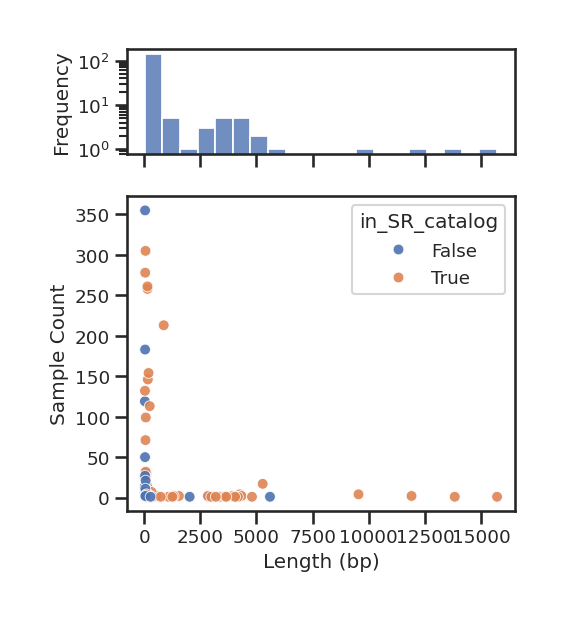

In [66]:

sns.set_theme(style="ticks", context="talk", font_scale=0.8)

#fig, axs = plt.subplots(2, 1, sharex=True)
fig, axs = plt.subplots(
    2, 1,
    figsize=(5, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)
sns.histplot(unique_seqfirst_numts, x='length_rep', bins=20, alpha=0.8, ax=axs[0])
sns.scatterplot(unique_seqfirst_numts, x='length_rep', y='sample_count', hue='in_SR_catalog', s=60, alpha=0.9, ax=axs[1])

axs[0].set_yscale("log")
#axs[1].set_xscale("log")
axs[0].set_ylabel("Frequency")
axs[1].set_ylabel("Sample Count")
axs[1].set_xlabel("Length (bp)")

plt.savefig(f"plots/fig6-numt_seqfirst_distribution.pdf", dpi=300)
plt.show()

In [67]:
# merge by chromosome first
merged = smaht_unique_numts.merge(gen_england_db, left_on="nchr", right_on="chromosome1",  how="left", suffixes=("", "_db"))
TOL = 100

merged["bp_ok"] = (
    ((abs(merged["nuclearGenome_breakpoint1"] - TOL)) < merged["npos_rep"]) & ((abs(merged["nuclearGenome_breakpoint2"] + TOL)) > merged["npos_rep"]))

matched_numts = (
    merged
    .loc[merged["bp_ok"], "numt_long"]
    .unique()
)

smaht_unique_numts["in_SR_catalog"] = (
    smaht_unique_numts["numt_long"].isin(matched_numts)
)

smaht_w_england = merged[merged['bp_ok'] == True]

smaht_unique_numts.to_csv('smaht_benchmarking_tissue_unique_numts.csv', sep='\t', index=False)

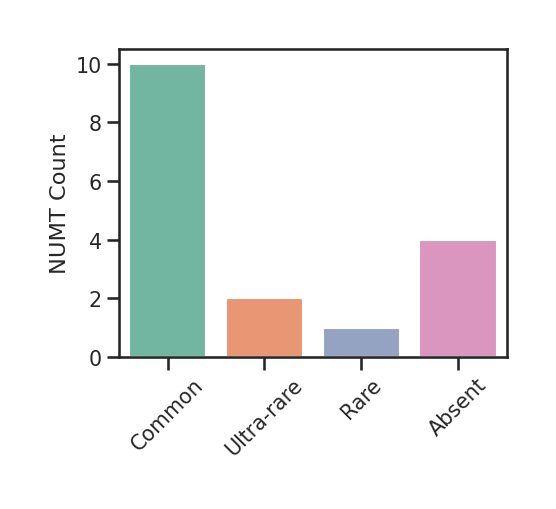

In [68]:
freq_counts = smaht_w_england['Frequency_Group'].value_counts().reset_index()
freq_counts.loc[len(freq_counts)] = ['Absent', len(smaht_unique_numts[smaht_unique_numts['in_SR_catalog'] == False])]

sns.set_theme(style="ticks", context="talk", font_scale=0.9)
plt.figure(figsize=(5,4))
sns.barplot(freq_counts, x='Frequency_Group', y='count', hue='Frequency_Group', palette='Set2', width=0.8)
plt.xlabel('')
plt.xticks(rotation=45)
plt.ylabel('NUMT Count')

plt.savefig(f"plots/fig6-numts_SR_catalog.pdf", dpi=300)
plt.show()

In [69]:
# merge smaht with seqfirst dbs
merged = smaht_unique_numts.merge(unique_seqfirst_numts, on="nchr",  how="left", suffixes=("", "_db"))
TOL = 100

merged["bp_ok"] = (
    (abs(merged["npos_rep"] - merged["npos_rep_db"]) < TOL ))

matched_numts = (
    merged
    .loc[merged["bp_ok"], "numt_long"]
    .unique()
)

smaht_unique_numts["present_in_seqfirst_db"] = (
    smaht_unique_numts["numt_long"].isin(matched_numts)
)

smaht_unique_numts

,index,numt_long,nchr,npos_rep,length_rep,mstart_rep,mend_rep,in_SR_catalog,present_in_seqfirst_db
0,0,chr11_100145004_59_11499_11557,chr11,100145004,59,11499,11557,True,True
1,4,chr11_4635113_40_16423_16462,chr11,4635113,40,16423,16462,False,True
2,10,chr11_49862017_60_1_60,chr11,49862017,60,1,60,True,True
3,15,chr11_77501999_32_13648_13679,chr11,77501999,32,13648,13679,False,True
4,17,chr12_6247321_66_12160_12225,chr12,6247321,66,12160,12225,True,True
5,18,chr1_37611748_72_8935_9006,chr1,37611748,72,8935,9006,True,True
6,20,chr1_54625173_41_1573_1613,chr1,54625173,41,1573,1613,False,True
7,25,chr21_9676568_870_12358_13227,chr21,9676568,870,12358,13227,True,True
8,29,chr2_213419058_35_15066_15100,chr2,213419058,35,15066,15100,True,True
9,33,chr2_33667411_246_14777_15022,chr2,33667411,246,14777,15022,True,True


In [70]:
b = smaht_unique_numts.merge(unique_seqfirst_numts[['numt_long', 'sample_count', 'PAF', 'Frequency_Group']], on='numt_long', how='left').sort_values('PAF')
b.to_csv('tables/benchmarking_unique_numts.csv', index=False)

In [ ]:
# from collections import Counter
# from Bio import SeqIO
# import itertools

# # generate all possible 3-mers
# bases = ['A','C','G','T']
# kmers = [''.join(p) for p in itertools.product(bases, repeat=3)]

# counts = Counter()

# for record in SeqIO.parse("/net/nwgc/vol1/home/czaka/ref/GRCh38_no_alt_analysis_set.fasta","fasta"):
#     print(record.id)
#     if record.id in valid_chroms:
#         seq = str(record.seq).upper()
        
#         for kmer in kmers:
#             counts[kmer] += seq.count(kmer)

# tri_df = pd.DataFrame.from_dict(counts, orient='index').reset_index()
# tri_df.columns = ['trinuc', 'kmer_count']
# tri_df.to_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/hg38_chr1-22XY_trinucleotide_frequencies.csv', index=False)


chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
chr21
chr22
chrX
chrY
chrM
chr1_KI270706v1_random
chr1_KI270707v1_random
chr1_KI270708v1_random
chr1_KI270709v1_random
chr1_KI270710v1_random
chr1_KI270711v1_random
chr1_KI270712v1_random
chr1_KI270713v1_random
chr1_KI270714v1_random
chr2_KI270715v1_random
chr2_KI270716v1_random
chr3_GL000221v1_random
chr4_GL000008v2_random
chr5_GL000208v1_random
chr9_KI270717v1_random
chr9_KI270718v1_random
chr9_KI270719v1_random
chr9_KI270720v1_random
chr11_KI270721v1_random
chr14_GL000009v2_random
chr14_GL000225v1_random
chr14_KI270722v1_random
chr14_GL000194v1_random
chr14_KI270723v1_random
chr14_KI270724v1_random
chr14_KI270725v1_random
chr14_KI270726v1_random
chr15_KI270727v1_random
chr16_KI270728v1_random
chr17_GL000205v2_random
chr17_KI270729v1_random
chr17_KI270730v1_random
chr22_KI270731v1_random
chr22_KI270732v1_random
chr22_KI270733v1_random
chr22_KI270734v1_random
chr22_KI270735v1

In [ ]:
# from collections import Counter
# from Bio import SeqIO
# import itertools

# # generate all possible 3-mers
# bases = ['A','C','G','T']
# kmers = [''.join(p) for p in itertools.product(bases, repeat=3)]

# counts = Counter()

# for record in SeqIO.parse("/net/nwgc/vol1/home/czaka/tools/mitoscope/resources/MT.fasta","fasta"):
#     seq = str(record.seq).upper()
    
#     for kmer in kmers:
#         counts[kmer] += seq.count(kmer)

# mito_tri_df = pd.DataFrame.from_dict(counts, orient='index').reset_index()
# mito_tri_df.columns = ['trinuc', 'kmer_count']
# mito_tri_df.to_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/mt_trinucleotide_frequencies.csv', index=False)


In [119]:
def rev_comp(sequence):
    bases = {'A':'T', 'T': 'A', 'G':'C', 'C':'G'}
    
    new_seq = ''
    for nuc in sequence:
        new_seq = bases[nuc] + new_seq
    return new_seq

mito_tri_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/mt_trinucleotide_frequencies.csv')
mito_tri_df['exp_prop'] = mito_tri_df['kmer_count'] / mito_tri_df['kmer_count'].sum()
mito_tri_df['trinuc_collapsed'] = np.where(mito_tri_df['trinuc'].str[1].isin(['A', 'G']), mito_tri_df['trinuc'].apply(rev_comp), mito_tri_df['trinuc'])
mito_tri_df = mito_tri_df.groupby(['trinuc_collapsed']).sum().reset_index()
mito_tri_df

nuc_tri_df = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/hg38_chr1-22XY_trinucleotide_frequencies.csv')
nuc_tri_df['exp_prop'] = nuc_tri_df['kmer_count'] / nuc_tri_df['kmer_count'].sum()
nuc_tri_df['trinuc_collapsed'] = np.where(nuc_tri_df['trinuc'].str[1].isin(['A', 'G']), nuc_tri_df['trinuc'].apply(rev_comp), nuc_tri_df['trinuc'])
nuc_tri_df = nuc_tri_df.groupby(['trinuc_collapsed']).sum().reset_index()
nuc_tri_df

,trinuc_collapsed,trinuc,kmer_count,exp_prop
0,ACA,ACATGT,108867143,0.039154
1,ACC,ACCGGT,67377361,0.024232
2,ACG,ACGCGT,15031779,0.005406
3,ACT,ACTAGT,94371148,0.033940
4,ATA,ATATAT,108832129,0.039141
5,ATC,ATCGAT,78231773,0.028136
6,ATG,ATGCAT,107040211,0.038497
7,ATT,AATATT,145343907,0.052273
8,CCA,CCATGG,107257513,0.038575
9,CCC,CCCGGG,58810213,0.021151


In [127]:
tri = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/tables/seqfirst_unique_numts.trinuc.csv', sep='\t')

nuc_col = [col for col in tri if col.startswith('nuc')]
mito_col = [col for col in tri if col.startswith('mito')]

nuc_tri = pd.melt(tri, id_vars=['id'], value_vars=nuc_col, var_name='side', value_name='bases')
nuc_props = nuc_tri['bases'].value_counts().reset_index()
nuc_props['obs_prop'] = nuc_props['count'] / nuc_props['count'].sum()
nuc_props['converted_bases'] = np.where(nuc_props['bases'].str[1].isin(['A', 'G']), nuc_props['bases'].apply(rev_comp), nuc_props['bases'])
nuc_props = nuc_props.groupby(['converted_bases']).sum().reset_index()
nuc_props = pd.merge(nuc_props, nuc_tri_df[['trinuc_collapsed', 'exp_prop']], how='left', left_on='converted_bases', right_on='trinuc_collapsed')
nuc_props['log2_ratio'] = np.log2(nuc_props['obs_prop'] / nuc_props['exp_prop'])
nuc_props['genome'] = 'nuc'
nuc_props_long = pd.melt(nuc_props, id_vars=['converted_bases'], value_vars=['obs_prop','exp_prop', 'log2_ratio'],var_name='group', value_name='value')

mito_tri = pd.melt(tri, id_vars=['id'], value_vars=mito_col, var_name='side', value_name='bases')
mito_tri = mito_tri[mito_tri['bases'] != '-']
mito_props = mito_tri['bases'].value_counts().reset_index()
mito_props['obs_prop'] = mito_props['count'] / mito_props['count'].sum()
mito_props['converted_bases'] = np.where(mito_props['bases'].str[1].isin(['A', 'G']), mito_props['bases'].apply(rev_comp), mito_props['bases'])
mito_props = mito_props.groupby(['converted_bases']).sum().reset_index()
mito_props = pd.merge(mito_props, mito_tri_df[['trinuc_collapsed', 'exp_prop']], how='left', left_on='converted_bases', right_on='trinuc_collapsed')
mito_props['log2_ratio'] = np.log2(mito_props['obs_prop'] / mito_props['exp_prop'])
mito_props['genome'] = 'mito'
mito_props_long = pd.melt(mito_props, id_vars=['converted_bases'], value_vars=['obs_prop','exp_prop', 'log2_ratio'],var_name='group', value_name='value')

comb_df = pd.concat([nuc_props, mito_props])
comb_df

,converted_bases,bases,count,obs_prop,trinuc_collapsed,exp_prop,log2_ratio,genome
0,ACA,TGTACA,13,0.038690,ACA,0.039154,-0.017173,nuc
1,ACC,GGTACC,8,0.023810,ACC,0.024232,-0.025380,nuc
2,ACG,ACG,1,0.002976,ACG,0.005406,-0.861131,nuc
3,ACT,AGTACT,16,0.047619,ACT,0.033940,0.488538,nuc
4,ATA,TATATA,10,0.029762,ATA,0.039141,-0.395220,nuc
...,...,...,...,...,...,...,...,...
27,TCT,TCTAGA,25,0.038344,TCT,0.028912,0.407322,mito
28,TTA,TAATTA,19,0.029141,TTA,0.046598,-0.677203,mito
29,TTC,TTCGAA,28,0.042945,TTC,0.031922,0.427921,mito
30,TTG,CAATTG,9,0.013804,TTG,0.036438,-1.400381,mito


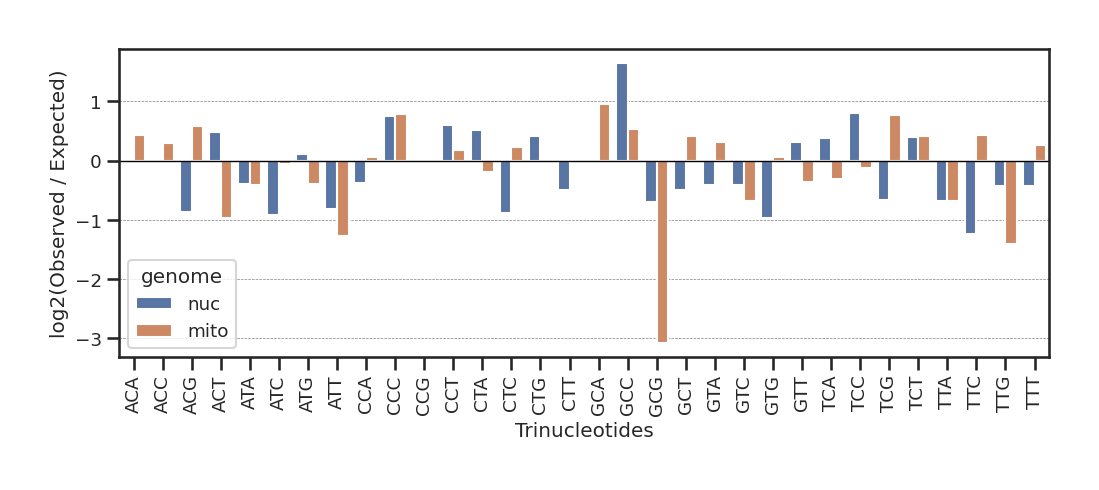

In [131]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)
plt.figure(figsize=(12,4))

sns.barplot(
    data=comb_df.sort_values('converted_bases'),
    x='converted_bases',
    y='log2_ratio',
    hue='genome'
)

plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y',color = 'gray', linestyle = '--', linewidth = 0.5)
plt.xticks(rotation=90)
plt.ylabel('log2(Observed / Expected)')
plt.xlabel('Trinucleotides')
plt.savefig(f"plots/fig6-trinucleotides.pdf", dpi=300)
plt.show()


In [132]:
observed = nuc_props['count'].values
expected = nuc_props['exp_prop'].values * observed.sum()

# normalize proportions to sum to 1
exp_prop = nuc_props['exp_prop'].values
exp_prop = exp_prop / exp_prop.sum()

expected = exp_prop * observed.sum()

chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)

print("Chi-square:", chi2)
print("p-value:", p)


Chi-square: 82.93850922560695
p-value: 1.2630510052486834e-06


In [133]:
observed = mito_props['count'].values
expected = mito_props['exp_prop'].values * observed.sum()

# normalize proportions to sum to 1
exp_prop = mito_props['exp_prop'].values
exp_prop = exp_prop / exp_prop.sum()

expected = exp_prop * observed.sum()

chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)

print("Chi-square:", chi2)
print("p-value:", p)


Chi-square: 88.53568897993969
p-value: 1.9233317080826244e-07


In [151]:
from scipy.stats import binomtest
import numpy as np

pvals = []
obs = nuc_props['count'].values
N = nuc_props['count'].sum()
for k, p in zip(obs, exp_prop):
    result = binomtest(k, N, p, alternative='two-sided')
    pvals.append(result.pvalue)

nuc_props['binom_p'] = pvals


from statsmodels.stats.multitest import multipletests

nuc_props['binom_p_adj'] = multipletests(
    nuc_props['binom_p'],
    method='fdr_bh'
)[1]

nuc_props[nuc_props['log2_ratio'] < -0.3]


,converted_bases,bases,count,obs_prop,trinuc_collapsed,exp_prop,log2_ratio,genome,binom_p,binom_p_adj
2,ACG,ACG,1,0.002976,ACG,0.005406,-0.861131,nuc,0.139311,0.374961
4,ATA,TATATA,10,0.029762,ATA,0.039141,-0.395220,nuc,0.406045,0.618735
5,ATC,GATATC,5,0.014881,ATC,0.028136,-0.918942,nuc,0.110492,0.374961
7,ATT,ATTAAT,10,0.029762,ATT,0.052273,-0.812586,nuc,0.232024,0.439240
8,CCA,CCATGG,10,0.029762,CCA,0.038575,-0.374194,nuc,0.766234,0.845499
13,CTC,CTCGAG,6,0.017857,CTC,0.032978,-0.884991,nuc,0.164045,0.374961
15,CTT,AAGCTT,10,0.029762,CTT,0.042129,-0.501346,nuc,0.878682,0.913968
18,GCG,GCG,1,0.002976,GCG,0.004854,-0.705586,nuc,0.141513,0.374961
19,GCT,AGCGCT,7,0.020833,GCT,0.029284,-0.491237,nuc,0.512311,0.659248
20,GTA,GTATAC,6,0.017857,GTA,0.023705,-0.408685,nuc,0.127839,0.374961


In [ ]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np

pvals = []
obs = mito_props['count'].values
N = mito_props['count'].sum()
exp = mito_props['exp_prop']
for k, p in zip(obs, exp):
    result = binomtest(k, N, p, alternative='two-sided')
    pvals.append(result.pvalue)
mito_props['binom_p'] = pvals

mito_props['binom_p_adj'] = multipletests(
    mito_props['binom_p'],
    method='fdr_bh'
)[1]

mito_props[mito_props['log2_ratio'] < -0.3]


,converted_bases,bases,count,obs_prop,trinuc_collapsed,exp_prop,log2_ratio,genome,binom_p,binom_p_adj
3,ACT,ACTAGT,12,0.018405,ACT,0.035936,-0.965341,mito,0.014834,0.079115
4,ATA,ATATAT,20,0.030675,ATA,0.040891,-0.414712,mito,0.233848,0.467696
6,ATG,CATATG,18,0.027607,ATG,0.036250,-0.392912,mito,0.293264,0.483738
7,ATT,AATATT,12,0.018405,ATT,0.044277,-1.266474,mito,0.000551,0.012187
18,GCG,GCG,1,0.001534,GCG,0.012982,-3.081399,mito,0.004596,0.029417
21,GTC,GACGTC,7,0.010736,GTC,0.017247,-0.683845,mito,0.288396,0.483738
23,GTT,AACGTT,19,0.029141,GTT,0.037567,-0.366396,mito,0.302336,0.483738
24,TCA,TCATGA,20,0.030675,TCA,0.037943,-0.306775,mito,0.410867,0.571641
28,TTA,TAATTA,19,0.029141,TTA,0.046598,-0.677203,mito,0.032234,0.140551
30,TTG,CAATTG,9,0.013804,TTG,0.036438,-1.400381,mito,0.000762,0.012187
